# SWNT Raman analysis

Single-wall carbon nanotube spectra, using the `ramanfit_swnt` package:

**load → Si calibration → RBM (→ diameter, candidate (n,m)) → joint D-G fit → 2D → quality metrics**

Unlike the amorphous/MW-carbon D/G fit in `ramanfit.ipynb`, this:

- models the low-frequency **RBM** band (diameter fingerprint), one Lorentzian
  per detected sub-band, above the 180 cm⁻¹ notch-filter edge,
- fits the whole **D-G region jointly over 1000–1700 cm⁻¹** with five
  Lorentzians — **D**, a broad **D″** disorder band (~1500–1535), the **G⁻/G⁺
  doublet**, and **D′** (~1600) — so the D-to-G valley is modelled instead of
  forced onto a straight baseline (R² ≈ 0.999 vs ≈ 0.98 for isolated windows),
- fits the full **second-order region** (G\*, the 2D triplet, D+D″, 2D″, 2D′)
  on a flat baseline,
- calibrates the shift axis against the **Si 520.7 cm⁻¹** substrate line.

In [1]:
import matplotlib.pyplot as plt
from ramanfit_swnt import (load_spectrum, analyze_swnt, SwntConfig,
                           choose_spectrum_file)
from ramanfit_swnt.report import plot_analysis, summary_text

DEFAULT_INFILE = "data/LA2026062502_no_laser_ObjX50D06_X0Y0.txt"  # 532 nm SWNT on Si
# Pop up a file chooser; cancel (or a headless run) keeps the default.
INFILE = choose_spectrum_file(default=DEFAULT_INFILE) or DEFAULT_INFILE

x, y = load_spectrum(INFILE)
print(f"{INFILE}: {len(x)} points, {x[0]:.0f}–{x[-1]:.0f} cm⁻¹")

data/LA2026062502_no_laser_ObjX50D06_X0Y0.txt: 25732 points, 150–3600 cm⁻¹


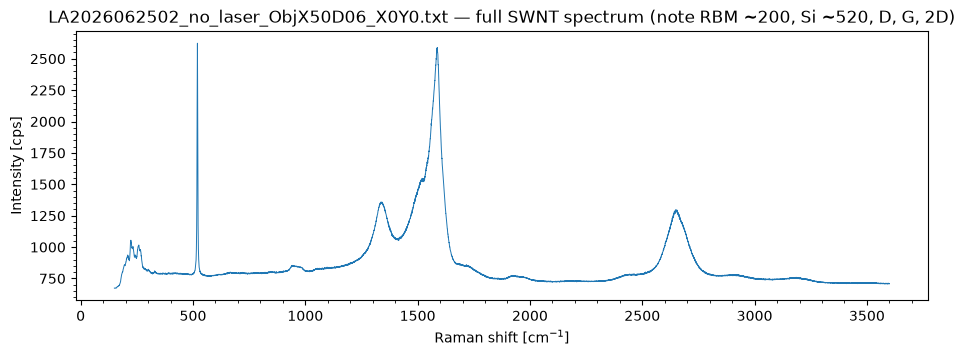

In [2]:
# Raw spectrum overview
import os
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(x, y, lw=0.7)
ax.set(xlabel="Raman shift [cm$^{-1}$]", ylabel="Intensity [cps]",
       title=f"{os.path.basename(INFILE)} — full SWNT spectrum "
             f"(note RBM ~200, Si ~520, D, G, 2D)")
ax.minorticks_on()
plt.show()

## Configure and run the pipeline

Adjust `laser_nm` (532/633/785), `gminus_lineshape` (`lorentzian` for
semiconducting, `bwf` for metallic tubes) or any region in `SwntConfig`.

In [3]:
# RBM shoulders this spectrum hides under stronger neighbours (~190, ~200 on
# the rising flank of the 210 band; ~300) are seeded manually — the prominence
# detector only sees local maxima, so buried shoulders need an explicit hint.
cfg = SwntConfig(laser_nm=532, gminus_lineshape="lorentzian",
                 rbm_extra_centers=(190.0, 200.0, 300.0))
res = analyze_swnt(x, y, cfg)
print(summary_text(res))

Si calibration: observed 519.62 cm-1, offset -1.08 cm-1 (nominal 520.7)

RBM peaks (diameter, candidate (n,m)):
    194.5 cm-1  d=1.27 nm   -
    205.2 cm-1  d=1.21 nm   (14,2)M, (15,0)M, (10,7)M
    211.6 cm-1  d=1.17 nm   (15,0)M, (10,7)M, (14,2)M
    224.4 cm-1  d=1.11 nm   (11,5)M, (8,8)M, (12,3)M
    234.0 cm-1  d=1.06 nm   (13,1)M, (12,3)M, (8,8)M
    244.9 cm-1  d=1.01 nm   (9,6)M, (13,1)M
    257.7 cm-1  d=0.96 nm   -
    268.0 cm-1  d=0.93 nm   -
    297.3 cm-1  d=0.83 nm   (9,2)S, (10,0)S
    335.2 cm-1  d=0.74 nm   (6,5)S, (9,1)S, (8,3)S

D-G joint fit (R²=0.9991):
  D   1339.2 cm-1 (FWHM 85)
  D'' 1511.6 cm-1 (FWHM 117, broad disorder band)
  G+  1589.5, G- 1567.7 (split 21.8 cm-1) -> semiconducting
  D'  1615.3 cm-1 (FWHM 25)
I(D)/I(G+) = 0.414

2D region (7 components, R²=0.9994):
  G*   2444.5 cm-1 (FWHM 144, height 42)
  2D   2614.8 cm-1 (FWHM 79, height 155)
  2D   2649.4 cm-1 (FWHM 61, height 335)
  2D   2687.8 cm-1 (FWHM 88, height 254)
  D+D''  2919.8 cm-1 (FWHM 162

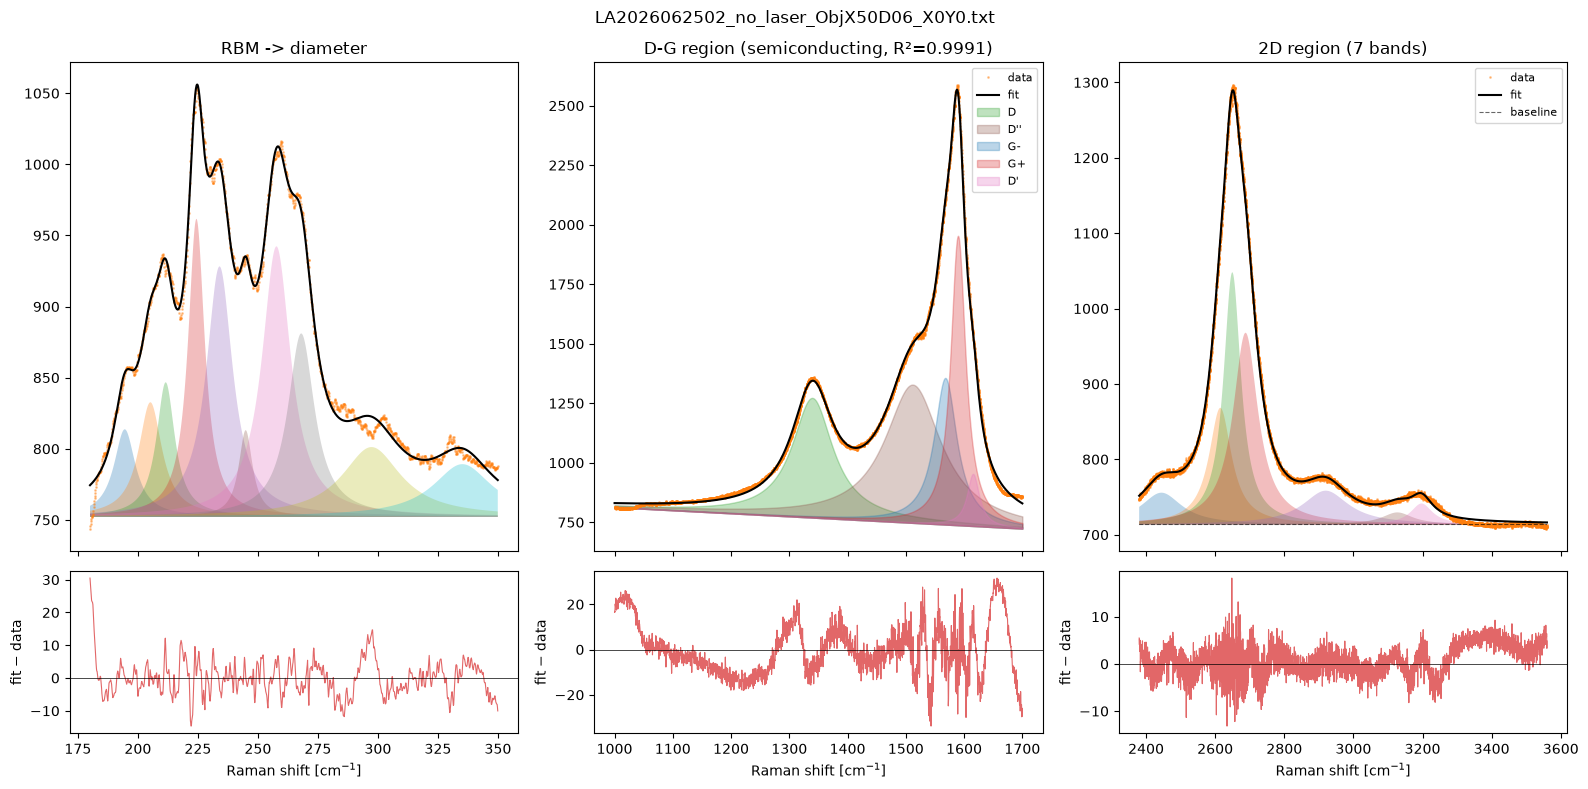

In [4]:
# Six-panel decomposition: RBM / D-G / 2D, each with data+fit over its residual
fig = plot_analysis(res, suptitle=os.path.basename(INFILE))
plt.show()

## RBM → diameter → candidate (n,m)

(n,m) candidates come from a first-order tight-binding Kataura model and are
**approximate** — see `ramanfit_swnt/kataura.py`.

In [5]:
for pk in res["rbm"]["peaks"]:
    nm = ", ".join(f"({c['n']},{c['m']}){c['type']}"
                   for c in pk.get("nm_candidates", [])[:3]) or "—"
    print(f"RBM {pk['center']:7.1f} cm⁻¹   d = {pk['diameter_nm']:.3f} nm   {nm}")

RBM   194.5 cm⁻¹   d = 1.275 nm   —
RBM   205.2 cm⁻¹   d = 1.209 nm   (14,2)M, (15,0)M, (10,7)M
RBM   211.6 cm⁻¹   d = 1.172 nm   (15,0)M, (10,7)M, (14,2)M
RBM   224.4 cm⁻¹   d = 1.105 nm   (11,5)M, (8,8)M, (12,3)M
RBM   234.0 cm⁻¹   d = 1.060 nm   (13,1)M, (12,3)M, (8,8)M
RBM   244.9 cm⁻¹   d = 1.013 nm   (9,6)M, (13,1)M
RBM   257.7 cm⁻¹   d = 0.962 nm   —
RBM   268.0 cm⁻¹   d = 0.925 nm   —
RBM   297.3 cm⁻¹   d = 0.834 nm   (9,2)S, (10,0)S
RBM   335.2 cm⁻¹   d = 0.740 nm   (6,5)S, (9,1)S, (8,3)S


## D-G band peaks (joint fit)

Centers, widths and uncertainties for the five components fit jointly over
1000–1700 cm⁻¹: **D**, a broad **D″** disorder band filling the D-to-G valley,
the **G⁻/G⁺** doublet, and **D′** (~1600, defect-activated, just above G⁺).
Finite `center ±` values confirm the fit is well-determined (not railed).

In [6]:
dg = res["dg"]
print(f"D-G joint fit  R² = {dg['r_squared']:.4f}  ({'metallic' if dg['metallic'] else 'semiconducting'})\n")
print(f"{'peak':4s} {'center':>9s} {'± (cm⁻¹)':>9s} {'FWHM':>7s} {'height':>9s}")
for rec in (dg['D'], dg['Dpp'], dg['G_minus'], dg['G_plus'], dg['Dprime']):
    ce = rec.get('center_stderr')
    ce_s = f"{ce:.2f}" if ce is not None else "  n/a"
    print(f"{rec['label']:4s} {rec['center']:9.1f} {ce_s:>9s} "
          f"{rec.get('fwhm', float('nan')):7.1f} {rec['height']:9.0f}")

D-G joint fit  R² = 0.9991  (semiconducting)

peak    center  ± (cm⁻¹)    FWHM    height
D       1339.2      0.07    85.4       503
D''     1511.6      0.34   117.2       581
G-      1567.7      0.33    47.4       616
G+      1589.5      0.06    31.1      1216
D'      1615.3      0.17    25.5       219


## 2D region (multi-component)

The whole second-order region (2380–3560 cm⁻¹) is fit with a **flat (constant)
baseline** at the true continuum floor — the far plateau past 2D' (~3400–3500
cm⁻¹). The apparent "hump" between the 2D and 2D' bands is not a curved
background but real **D+D″** (~2915) and **2D″** (~3105) combination bands, so
once those are fit explicitly the baseline stays horizontal. The band set
matches a reference Igor multipeak fit of this sample: **G\*** (~2446, iTOLA),
the **2D** triplet (~2655, main + two shoulders from the diameter distribution /
different (n,m) species), **D+D″**, **2D″**, and **2D'** (~3185, overtone of D').
The I(2D)/I(G) metric uses the dominant 2D peak.

In [7]:
t2d = res["twod_band"]
print(f"2D region: {len(t2d['peaks'])} components  (R² = {t2d['r_squared']:.4f})\n")
print(f"{'band':5s} {'center':>9s} {'FWHM':>7s} {'height':>9s}")
for pk in sorted(t2d["peaks"], key=lambda r: r["center"]):
    print(f"{pk['label']:5s} {pk['center']:9.1f} {pk['fwhm']:7.1f} {pk['height']:9.0f}")
print(f"\ndominant 2D {t2d['peak']['center']:.1f} cm⁻¹,  I(2D)/I(G⁺) = {res['quality']['I2D_IG']:.3f}")

2D region: 7 components  (R² = 0.9994)

band     center    FWHM    height
G*       2444.5   143.8        42
2D       2614.8    79.3       155
2D       2649.4    61.1       335
2D       2687.8    87.9       254
D+D''    2919.8   161.6        45
2D''     3127.1   109.1        16
2D'      3197.1    77.3        28

dominant 2D 2649.4 cm⁻¹,  I(2D)/I(G⁺) = 0.275


## Si calibration & quality metrics

In [8]:
cal = res["calibration"]
g = res["gband"]
q = res["quality"]
print(f"Si calibration applied: {cal['applied']}  (offset {cal['offset']:+.2f} cm⁻¹)")
print(f"G⁺ = {g['G_plus']['center']:.1f}, G⁻ = {g['G_minus']['center']:.1f} cm⁻¹")
print(f"character: {'metallic' if g['metallic'] else 'semiconducting'}")
quality = "low defects" if q['ID_IG'] < 0.2 else ("moderate defects" if q['ID_IG'] < 0.5 else "high defects")
print(f"I(D)/I(G⁺) = {q['ID_IG']:.3f}   ({quality})")
print(f"2D = {q['twod_center']:.1f} cm⁻¹,  I(2D)/I(G⁺) = {q['I2D_IG']:.3f}")

Si calibration applied: True  (offset -1.08 cm⁻¹)
G⁺ = 1589.5, G⁻ = 1567.7 cm⁻¹
character: semiconducting
I(D)/I(G⁺) = 0.414   (moderate defects)
2D = 2649.4 cm⁻¹,  I(2D)/I(G⁺) = 0.275


## Save a summary

In [9]:
with open("swnt_summary.txt", "w") as f:
    f.write(summary_text(res))
print("wrote swnt_summary.txt")

wrote swnt_summary.txt
